In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from cuml.svm import SVC
from sklearn.svm import SVC

#import cudf
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import fbeta_score
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score 


**PARDON MY UGLY CODE WRITING**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
#df = cudf.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv") 


In [3]:
def load_data(path):
  df = pd.read_csv(path)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df):
  df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train,x_test,y_train,y_test = train_test_split(
x,y, test_size=0.30, random_state=42)
  y_train.value_counts()
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    train_df = pd.concat([x_train, y_train], axis=1)

    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]

    return X_under, y_under



def evaluate(x_test,y_test,model,threshold):

  #y_prob = model.predict_proba(x_test).iloc[:,1] 
  # well use decision function here instead of the prob . the decision func gives the distance form the decsiosn boundary .... can be used for tuning
  y_dist = model.decision_function(x_test)
  y_pred = (y_dist > threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  score = accuracy_score(y_test,y_pred)
  print(score)
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  print(classification_report(y_test,y_pred))
  return y_pred

def grid_with_class_weights(x_train,y_train):
  
  
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  model = SVC(max_iter=1000,kernel='rbf')
# trying to use the GPU
  param_grid = {'C':[0.1,1,100,1000],
                'gamma':['scale'],
                'kernel':['rbf'], 
                'class_weight':['balanced']+[{0:w,1:y} for w in [1] for y in [100,587] ],
                   }
  
 # parameters = dict(penalty=penalty,C=C,class_weight=class_weight)
  #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1)
  grid = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=10,   # only try 10 combos
        cv=StratifiedKFold(shuffle=True),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
                        )
  grid.fit(x_train,y_train)
  print(grid.best_params_)
  print("the best score" + str(grid.best_score_))
  model = grid.best_estimator_
  threshold = threshold_from_cv(model,x_train,y_train) # gives the best threshold during the valid
  print(model.support_vectors_)
  return model,threshold

def grid_with_SMOTE(x_train,y_train):
     from sklearn.svm import SVC
     from imblearn.pipeline import Pipeline
     from imblearn.over_sampling import SMOTE
     model = SVC(max_iter=5000,kernel='rbf')
    #   PREVENTION OF DATA LEAKAGE IN CROSS VALIDATION 
    #using smote in pipeline to avoid data leakage into the cross train-validation which leads to incorrect score(overfit(not exactly)) 
    #The CV Split: When CV splits say 400 points into 5 folds, a synthetic point in Fold 1 likely has a "parent" or "neighbor" in Fold 2.
    #The Leak: When the model trains on Folds 2–5 and validates on Fold 1, it is effectively seeing data it already "knows" from the SMOTE step.
     pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', model)
                         ])
     #visualise(resampled)
     param_grid = {
    'model__C': [0.1, 1, 100, 1000],
    'model__gamma': ['scale'],
    'model__class_weight':['balanced']
}
    # grid = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        cv=StratifiedKFold(shuffle=True,random_state = 42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
                        )
     grid.fit(x_train,y_train)
     print("the best score" + str(grid.best_score_))
     print(grid.best_params_)
     model = grid.best_estimator_
     threshold = threshold_from_cv(model, x_train, y_train)
     
     return model,threshold

def grid_with_downsampling(x_train,y_train):
     model = SVC(max_iter=5000,kernel='rbf')
     x_under,y_under = undersample(x_train,y_train)
     #visualise(resampled)
     param_grid = {'C':[0.1,1,100,1000],
                'gamma':['scale'],
                   'class_weight':['balanced']
                   }
     #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
     model,
     param_distributions=param_grid,
     n_iter=10,   # only try 10 combos
     cv=StratifiedKFold(shuffle=True,random_state = 42),
     scoring='roc_auc',
     n_jobs=-1,
     verbose=1
            )
     grid.fit(x_under,y_under)
     print("te best params ")
     print(grid.best_params_)
     print("the best score" + str(grid.best_score_))
     model = grid.best_estimator_
     threshold = threshold_from_cv(model,x_train,y_train)
     return model,threshold
    
    
    
def oversample(x_train,y_train):
    oversample = SMOTE()
    #f = train_sample.drop(['Time','Class'],axis = 1)     #OMG i am forget that i already removed the time in the train_test_split 
    #target = df['Class'] 
    x_resampled,y_resampled = oversample.fit_resample(x_train,y_train)
    print(x_resampled.shape)
    print(y_resampled.shape)
    resampled = pd.concat([x_resampled, y_resampled], axis=1)                 # dont need this!! just made to visualise this!!!!!!!!
    sns.countplot(x="Class", data=resampled)
    return x_resampled,y_resampled,resampled
def AUC_ROC_evaluate(model,x_test,y_test,threshold):
     
    y_pred = evaluate(x_test,y_test,model,threshold) #  done here next is the AUC _ROC
    y_score = model.decision_function(x_test)
    #y_pred = model.predict(x_test)
    #y_prob = model.predict_proba(x_test)#[:,1]## just the positve outcomes
    #y_prob = y_prob.iloc[:,1]
    auc_score = roc_auc_score(y_test,y_score)
    print(auc_score)
    model_FPR, model_TPR,thresholds = roc_curve(y_test,y_score) 
    plt.plot(model_FPR,model_TPR,marker = '.',label = 'SVC')
    plt.xlabel("false pos rate")
    plt.ylabel("true pos rate")
    plt.legend()
    plt.show()
   # print("the j statistic for threshold " + str(model_TPR-model_FPR))"""





def threshold_from_cv(model, x_train, y_train):

    # Get validation scores from CV
    y_score = cross_val_predict( ###please refer the documentation for clarity
        model,
        x_train,
        y_train,
        cv=StratifiedKFold(shuffle=True,random_state=42),
        method='decision_function',
        n_jobs=-1
    )

    fpr, tpr, thresholds = roc_curve(y_train, y_score) # thresholds give an array 

    # max recall but not so stupid precision!!!!
    j_scores = tpr - fpr
    idx = j_scores.argmax()

    print("Best Threshold (CV):", thresholds[idx])
    print("Recall:", tpr[idx])
    print("FPR:", fpr[idx])

    return thresholds[idx]


(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


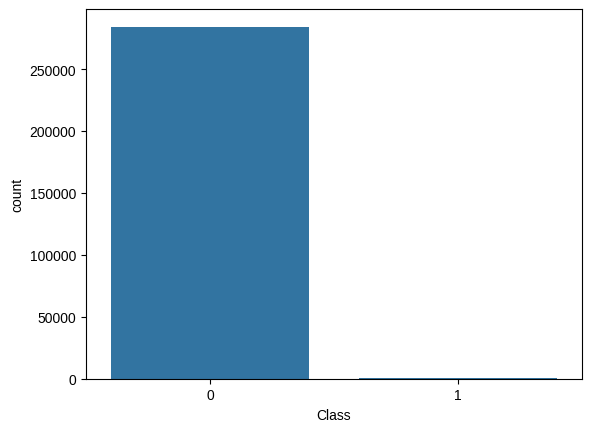

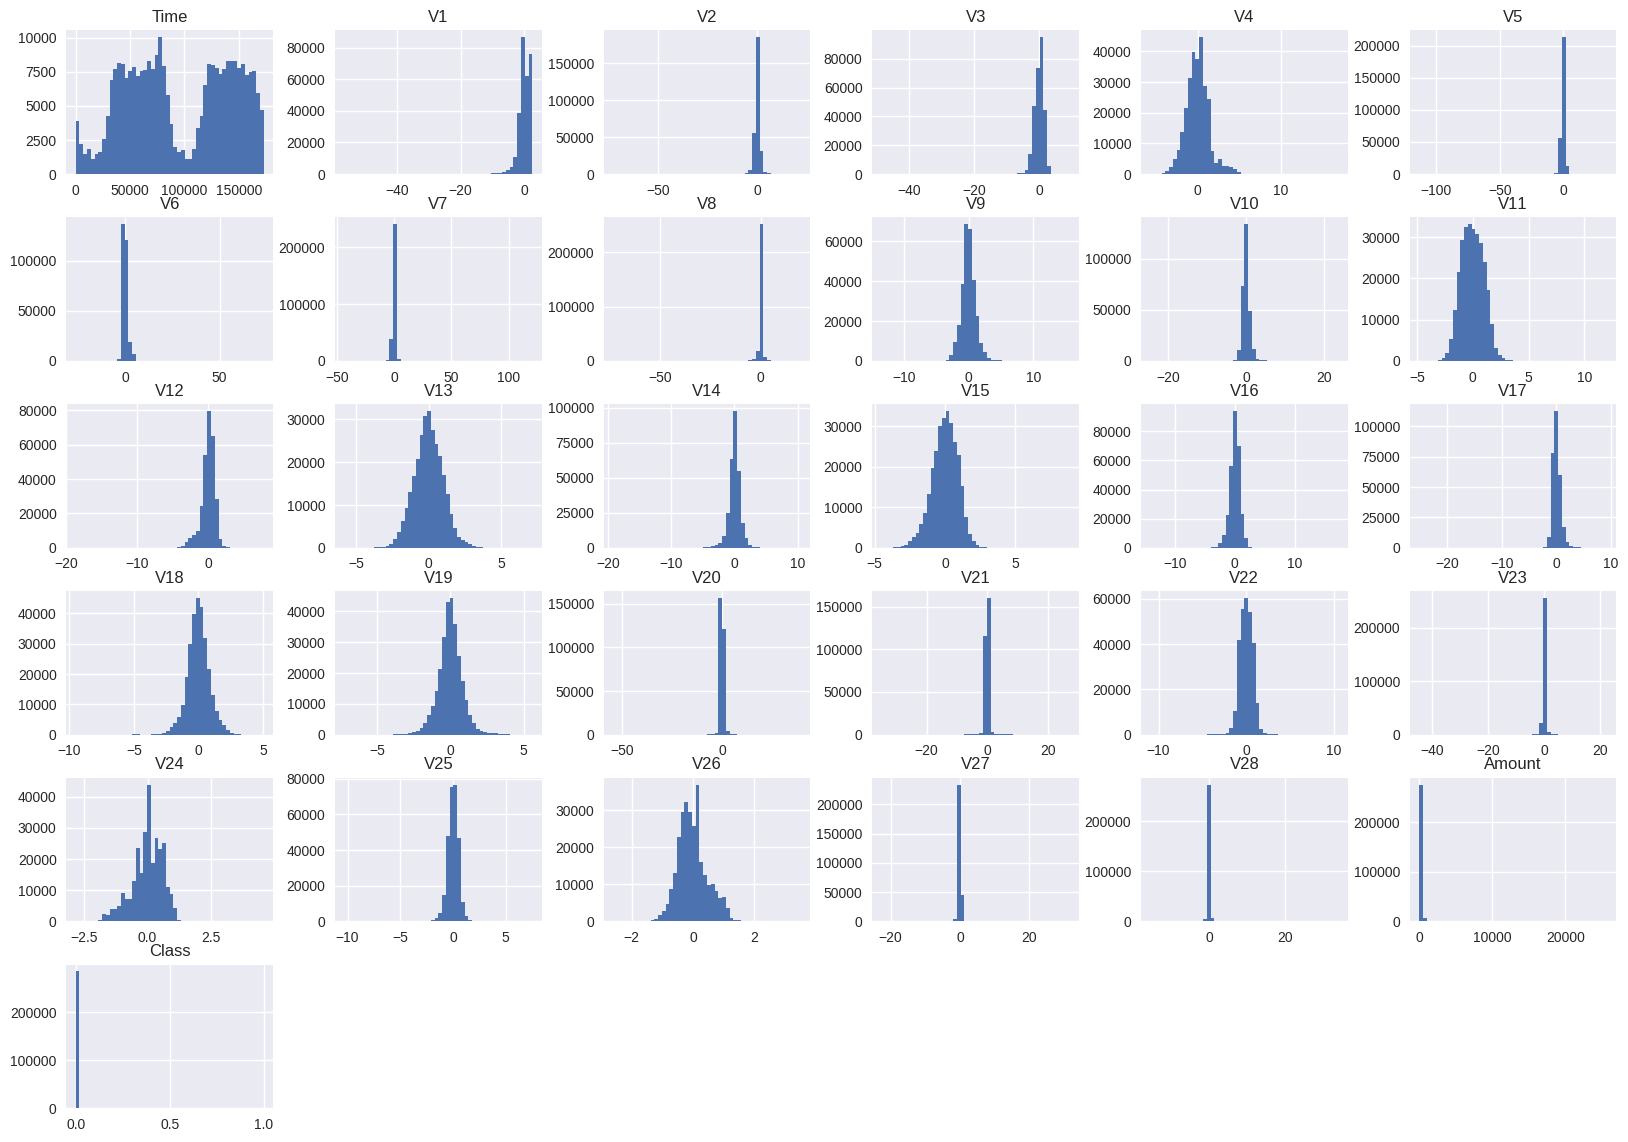

In [4]:
visualise(df)


In [5]:
x_train, x_test,y_train, y_test = trainsplit(df)


**With_Class_weights**

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

{'kernel': 'rbf', 'gamma': 'scale', 'class_weight': {0: 1, 1: 100}, 'C': 0.1}
the best score0.6504339357489463


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

Best Threshold (CV): 0.9954385950231884
Recall: 0.37640449438202245
FPR: 0.03401873291525969
[[ 4.03686839e-01  1.89406491e+00 -2.05285384e+00 ...  1.47984050e-01
  -4.75816634e-02  2.24000000e+00]
 [-5.95268404e-01  1.26475254e+00 -6.41662426e-02 ... -1.38927983e-01
  -1.63417277e-01  2.69000000e+00]
 [ 1.19661369e+00  1.13675624e+00 -1.65047305e+00 ...  4.63107647e-02
   9.10611172e-02  4.75000000e+00]
 ...
 [-2.88004235e+00  5.22544231e+00 -1.10633303e+01 ...  1.42771310e+00
   5.83172486e-01  1.00000000e+00]
 [ 1.86822575e+00  1.36307704e+00 -1.99493428e+00 ... -6.62944886e-03
   1.72577349e-02  3.14000000e+00]
 [ 1.88961791e+00  1.07309853e+00 -1.67801752e+00 ...  3.16687807e-02
   3.58833226e-02  3.22000000e+00]]
0.9714078391442248
[[82955  2352]
 [   91    45]]


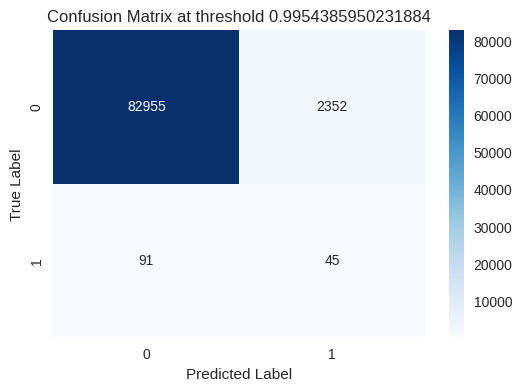

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85307
           1       0.02      0.33      0.04       136

    accuracy                           0.97     85443
   macro avg       0.51      0.65      0.51     85443
weighted avg       1.00      0.97      0.98     85443

0.5710436665082999


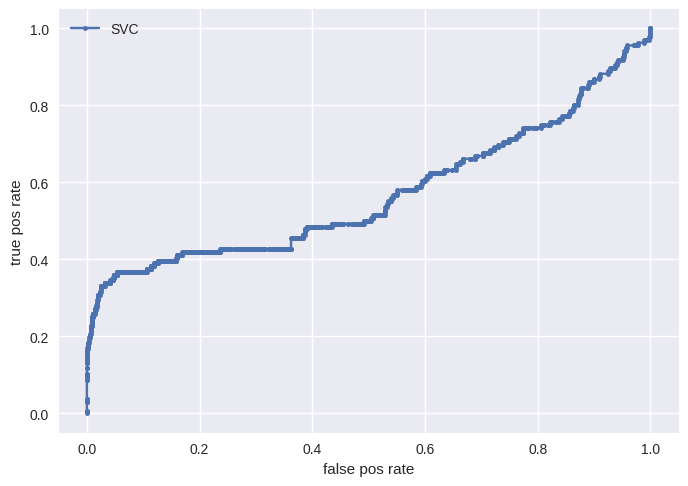

In [6]:
model,threshold = grid_with_class_weights(x_train,y_train)

y_pred = AUC_ROC_evaluate(model,x_test,y_test,threshold)




**with_upsampling**

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs wer

the best score0.8609655338100735
{'model__gamma': 'scale', 'model__class_weight': 'balanced', 'model__C': 0.1}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs wer

Best Threshold (CV): 0.16227801377106255
Recall: 0.5702247191011236
FPR: 0.010718162083936325
0.9993094811745842
[[85290    17]
 [   42    94]]


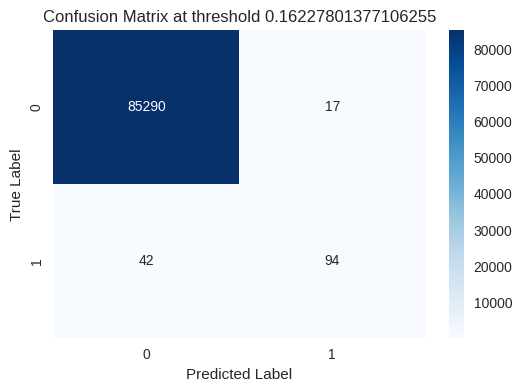

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.85      0.69      0.76       136

    accuracy                           1.00     85443
   macro avg       0.92      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443

0.8624492231862911


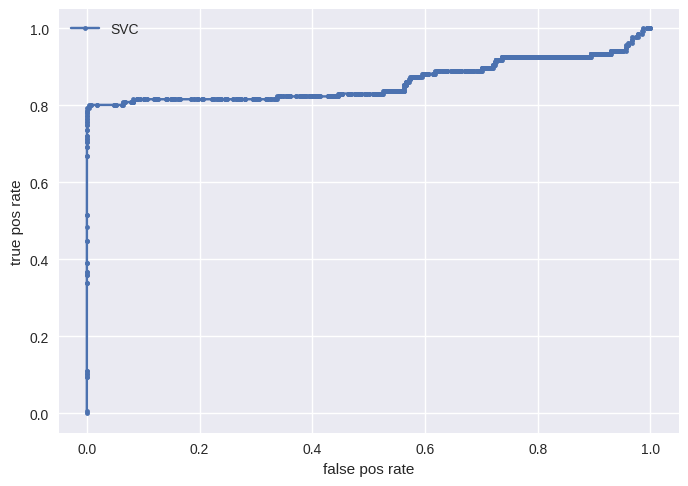

In [7]:
model,threshold = grid_with_SMOTE(x_train,y_train)

y_pred = AUC_ROC_evaluate(model,x_test,y_test,threshold)


**grid with downsapmpling**

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_ite

te best params 
{'gamma': 'scale', 'class_weight': 'balanced', 'C': 1000}
the best score0.9697623928232935


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider

Best Threshold (CV): -0.2714857201039038
Recall: 0.8117977528089888
FPR: 0.6452001929570671
0.9439977528878901
[[80533  4774]
 [   11   125]]


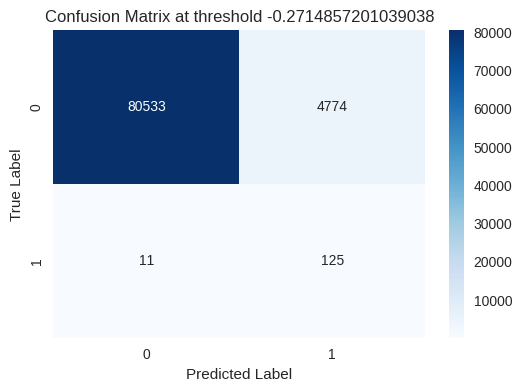

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     85307
           1       0.03      0.92      0.05       136

    accuracy                           0.94     85443
   macro avg       0.51      0.93      0.51     85443
weighted avg       1.00      0.94      0.97     85443

0.9804545037680515


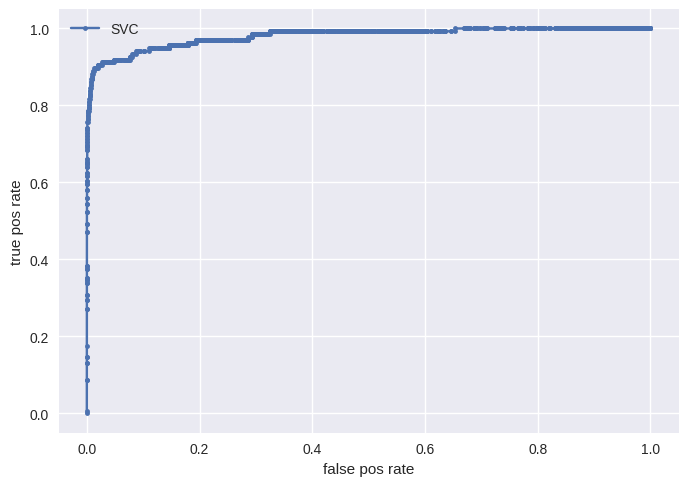

In [8]:
model,threshold = grid_with_downsampling(x_train,y_train)
  
y_pred = AUC_ROC_evaluate(model,x_test,y_test,threshold)
